<a href="https://colab.research.google.com/github/andrealoy/PathMNISTClassification/blob/main/pathmnist_classification_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA

In [ ]:
!pip install medmnist

In [ ]:
!git clone https://github.com/andrealoy/PathMNISTClassification.git

Cloning into 'PathMNISTClassification'...
remote: Enumerating objects: 16, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 16 (delta 4), reused 14 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (16/16), 939.79 KiB | 22.38 MiB/s, done.
Resolving deltas: 100% (4/4), done.


In [ ]:
%cd PathMNISTClassification

/content/PathMNISTClassification/PathMNISTClassification


In [ ]:
%cd /content/PathMNISTClassification

/content/PathMNISTClassification


In [ ]:
#%load_ext autoreload
#%autoreload 2
import medmnist
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms

from torch.utils.data import DataLoader
from utils import *
from medmnist import PathMNIST,INFO
from pathlib import Path
from tqdm import tqdm

In [ ]:
ROOT_DIR = "./data"
# Create the directory if it doesn't exist
Path(ROOT_DIR).mkdir(parents=True, exist_ok=True)
SEED = 42
IMG_SIZE = (28, 28)
HIDDEN_SIZE = 256
CHANNELS = 3
NUM_CLASSES = 9
BATCH_SIZE = 128
EPOCHS = 10
LEARNING_RATE = 1e-3

In [ ]:
# Activation de la seed pour rendre l'entraînement reproductible
# (initialisation des poids, shuffle des batches, etc.)

import random
import numpy as np

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
dataset = PathMNIST(root=ROOT_DIR, split="train", download=True)

In [ ]:
# Load PathMNIST info
data_flag = 'pathmnist'
info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])

In [ ]:
info

{'python_class': 'PathMNIST',
 'description': 'The PathMNIST is based on a prior study for predicting survival from colorectal cancer histology slides, providing a dataset (NCT-CRC-HE-100K) of 100,000 non-overlapping image patches from hematoxylin & eosin stained histological images, and a test dataset (CRC-VAL-HE-7K) of 7,180 image patches from a different clinical center. The dataset is comprised of 9 types of tissues, resulting in a multi-class classification task. We resize the source images of 3×224×224 into 3×28×28, and split NCT-CRC-HE-100K into training and validation set with a ratio of 9:1. The CRC-VAL-HE-7K is treated as the test set.',
 'url': 'https://zenodo.org/records/10519652/files/pathmnist.npz?download=1',
 'MD5': 'a8b06965200029087d5bd730944a56c1',
 'url_64': 'https://zenodo.org/records/10519652/files/pathmnist_64.npz?download=1',
 'MD5_64': '55aa9c1e0525abe5a6b9d8343a507616',
 'url_128': 'https://zenodo.org/records/10519652/files/pathmnist_128.npz?download=1',
 'MD5

In [ ]:
print(f"Number of samples: {len(dataset)}")

Number of samples: 89996


In [ ]:
for key, value in dataset.info['label'].items():
    print(f"Class {key} : {value}")

Class 0 : adipose
Class 1 : background
Class 2 : debris
Class 3 : lymphocytes
Class 4 : mucus
Class 5 : smooth muscle
Class 6 : normal colon mucosa
Class 7 : cancer-associated stroma
Class 8 : colorectal adenocarcinoma epithelium


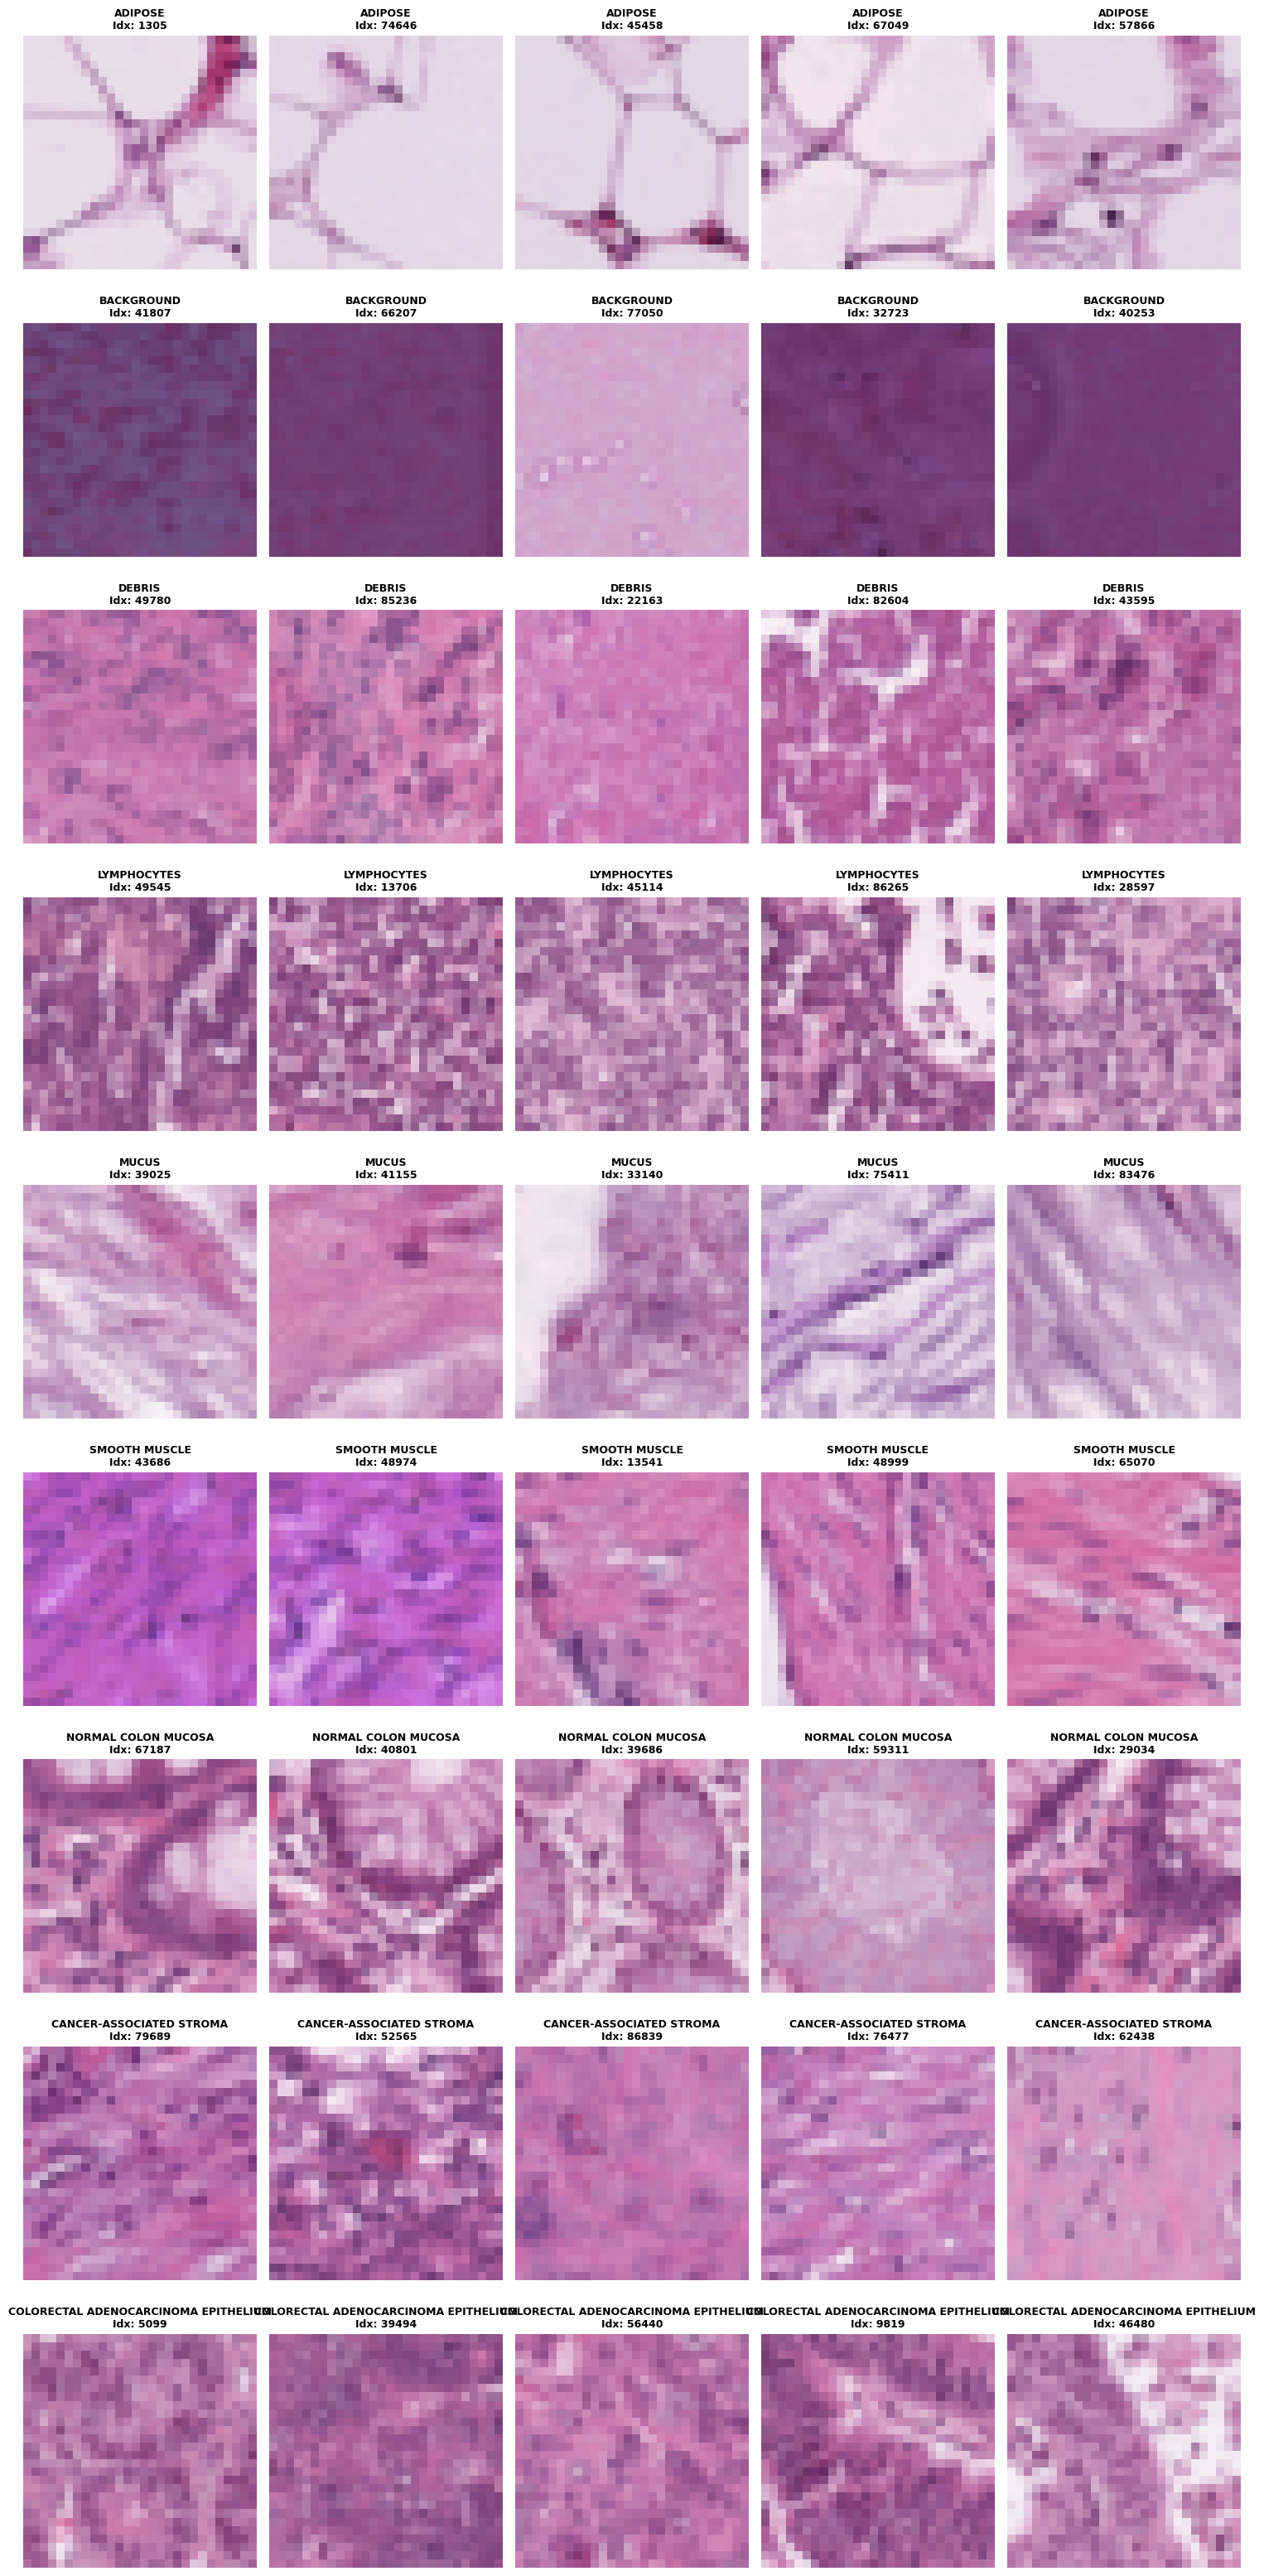

In [ ]:
display_medmnist_samples(dataset,"*",5)

En observant plusieurs images de la classe Debris et en les comparant avec celles de la classe Background, on remarque des différences visuelles nettes.

Les images de la classe Debris présentent généralement des fragments irréguliers et des structures plus hétérogènes. On y observe souvent une texture plus complexe, avec des amas de formes ou des contours marqués qui se détachent du reste de l’image. Les couleurs peuvent aussi varier davantage, avec des zones plus sombres ou plus denses.

À l’inverse, les images de la classe Background apparaissent plus uniformes et plus lisses. La texture est généralement plus homogène, avec peu de structures distinctes ou de contours marqués. Les couleurs sont aussi plus régulières, souvent dominées par des tons rosés ou violacés relativement constants.

Ainsi, les images Debris se caractérisent par des textures irrégulières et des motifs plus complexes, tandis que les images Background sont plus homogènes et moins structurées visuellement.

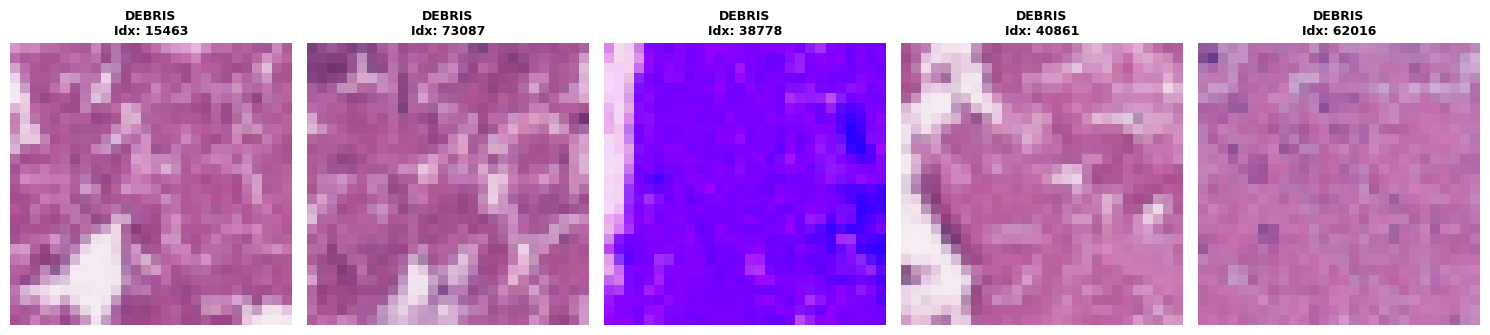

In [ ]:
display_medmnist_samples(dataset,"debris",5)

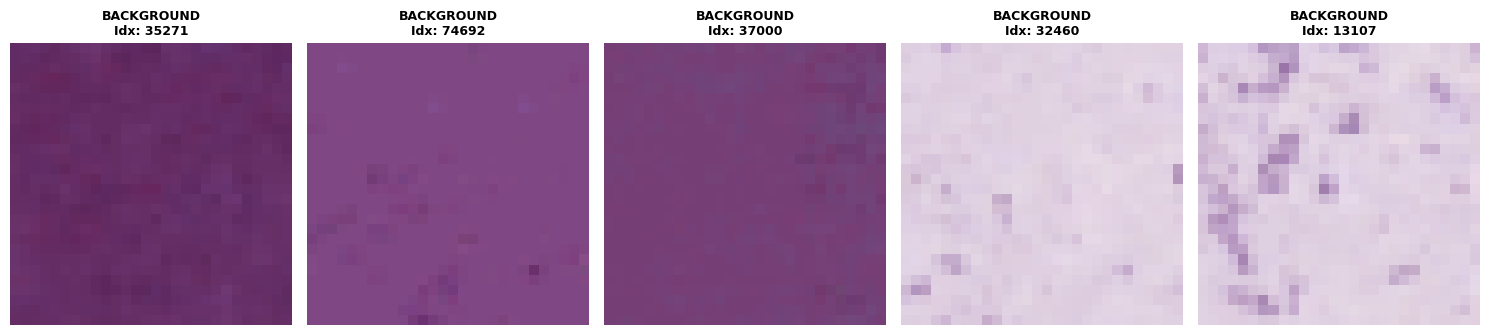

In [ ]:
display_medmnist_samples(dataset,"background",5)

In [ ]:
print_dataset_structure(dataset)

--- Dataset Structure: PATHMNIST ---
Total samples: 89996
Image shape: (89996, 28, 28, 3)
Labels shape: (89996, 1)
Mode: RGB


In [ ]:
plot_class_distribution(dataset)

--- Pixel Stats: Mean=168.25, Std=43.36, Min=0, Max=255 ---


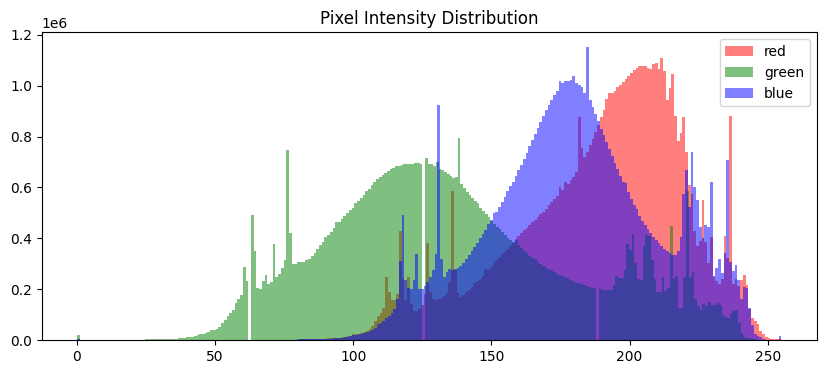

In [ ]:
show_pixel_stats(dataset)

--- Stats for Image Index: 15795 (Seed: 42) ---
Mean: 108.66 | Std: 27.71 | Min: 11 | Max: 139
Shape: (28, 28, 3)


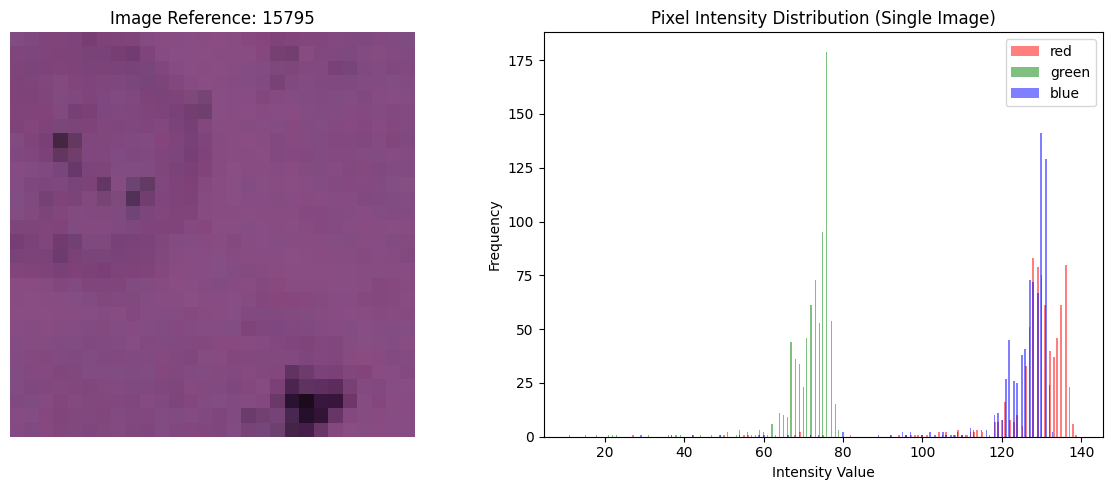

In [ ]:
show_random_pixel_stats(dataset)

Nous avons calculé la moyenne et l’écart-type des intensités de pixels pour chaque canal RGB sur une image du jeu d’entraînement. Les valeurs obtenues sont différentes des statistiques d’ImageNet. Cela est attendu car les images du dataset PathMNIST sont des images histopathologiques avec des distributions de couleurs spécifiques (principalement des teintes roses et violettes dues à la coloration H&E), tandis qu’ImageNet contient des images naturelles avec une distribution de couleurs plus variée. Les statistiques de pixels ne sont donc pas proches de celles d’ImageNet.

+ nos pixels sont normalisés entre -1 et 1

alors que ImageNet est normalisé autour de 0-1 puis standardisé

# Preparing the data

In [ ]:
# Simple Preprocessing
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [ ]:
# 2. Load the 3 splits (it only downloads once!)
train_dataset = PathMNIST(root=ROOT_DIR, split="train", transform=transform, download=False)
val_dataset   = PathMNIST(root=ROOT_DIR, split="val",   transform=transform, download=False)
test_dataset  = PathMNIST(root=ROOT_DIR, split="test",  transform=transform, download=False)

# 3. Create your loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

# MLP

In [ ]:
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes, dropout_prob=0.5):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, num_classes)

        self.dropout = nn.Dropout(dropout_prob)

    def forward(self, x):
        # Flatten the input
        x = x.view(x.size(0), -1)
        # First hidden layer + ReLU + Dropout
        x = F.relu(self.fc1(x))
        x = self.dropout(x)

        # Second hidden layer + ReLU + Dropout
        x = F.relu(self.fc2(x))
        x = self.dropout(x)

        # Output layer
        x = self.fc3(x)
        return x


In [ ]:
baseline = MLP(input_size=IMG_SIZE[0] * IMG_SIZE[1] * CHANNELS, hidden_size=HIDDEN_SIZE, num_classes=NUM_CLASSES)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
baseline = baseline.to(device)
print(baseline)

MLP(
  (fc1): Linear(in_features=2352, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=9, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline.parameters(), lr=LEARNING_RATE)

Training loop

In [ ]:
def train_and_evaluate(model, train_loader, val_loader, criterion, optimizer, epochs, device):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        # --- TRAINING PHASE ---
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device).squeeze().long()

            # Forward + Backward
            outputs = model(images)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Stats
            train_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            train_correct += predicted.eq(labels).sum().item()
            train_total += labels.size(0)
            loop.set_postfix(loss=loss.item())

        # --- VALIDATION PHASE (Required for Q2.1) ---
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device).squeeze().long()
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                val_correct += predicted.eq(labels).sum().item()
                val_total += labels.size(0)

        # Store metrics
        history['train_loss'].append(train_loss / train_total)
        history['train_acc'].append(100. * train_correct / train_total)
        history['val_loss'].append(val_loss / val_total)
        history['val_acc'].append(100. * val_correct / val_total)

        print(f"Summary Epoch {epoch+1}: Val Loss: {history['val_loss'][-1]:.4f} | Val Acc: {history['val_acc'][-1]:.2f}%")

    return history

In [ ]:
history = train_and_evaluate(baseline, train_loader, val_loader, criterion, optimizer, EPOCHS, device)

Epoch 1/10: 100%|██████████| 704/704 [00:23<00:00, 30.30it/s, loss=1.36]


Summary Epoch 1: Val Loss: 1.3368 | Val Acc: 49.67%


Epoch 2/10: 100%|██████████| 704/704 [00:23<00:00, 30.13it/s, loss=1.27]


Summary Epoch 2: Val Loss: 1.2669 | Val Acc: 52.81%


Epoch 3/10: 100%|██████████| 704/704 [00:23<00:00, 29.45it/s, loss=1.5]


...

Summary Epoch 8: Val Loss: 1.3027 | Val Acc: 50.42%


Epoch 9/10: 100%|██████████| 704/704 [00:23<00:00, 29.40it/s, loss=1.09]


Summary Epoch 9: Val Loss: 1.2999 | Val Acc: 51.15%


Epoch 10/10: 100%|██████████| 704/704 [00:23<00:00, 29.77it/s, loss=1.54]


Summary Epoch 10: Val Loss: 1.3090 | Val Acc: 52.02%


Test accuracy: 0.13454539458880674


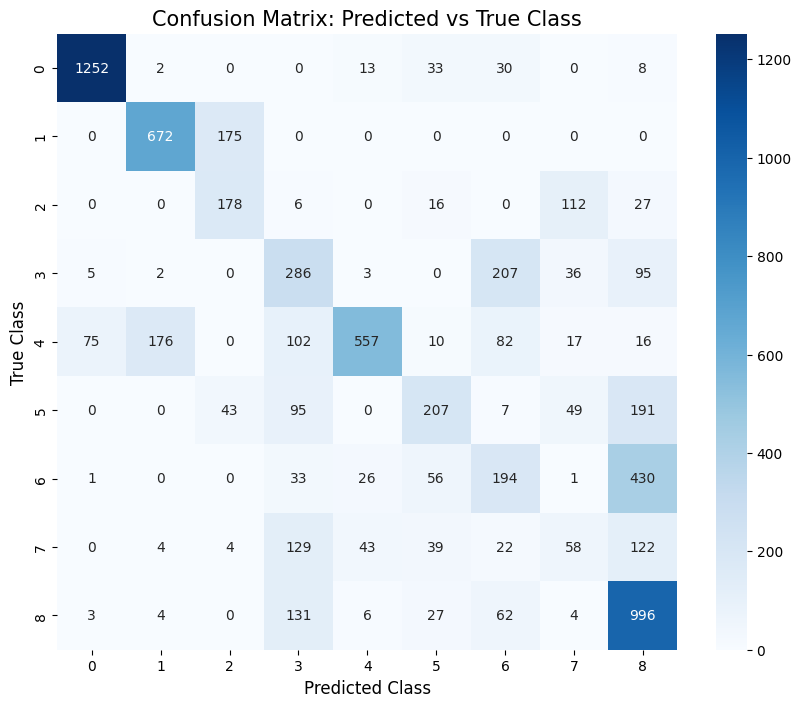

array([[1252,    2,    0,    0,   13,   33,   30,    0,    8],
       [   0,  672,  175,    0,    0,    0,    0,    0,    0],
       [   0,    0,  178,    6,    0,   16,    0,  112,   27],
       [   5,    2,    0,  286,    3,    0,  207,   36,   95],
       [  75,  176,    0,  102,  557,   10,   82,   17,   16],
       [   0,    0,   43,   95,    0,  207,    7,   49,  191],
       [   1,    0,    0,   33,   26,   56,  194,    1,  430],
       [   0,    4,    4,  129,   43,   39,   22,   58,  122],
       [   3,    4,    0,  131,    6,   27,   62,    4,  996]])

In [ ]:
# Évaluation sur l'ensemble de test (exigence de l'énoncé)
# La boucle d'entraînement affiche les métriques train/validation.
# Cette cellule calcule la performance finale sur le jeu de test
# (accuracy et matrice de confusion).

@torch.no_grad()
def eval_test(model, loader, device):
    model.eval()
    y_true, y_pred = [], []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        outputs = model(x)
        preds = torch.argmax(outputs, dim=1)

        y_true.extend(y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

    acc = np.mean(np.array(y_true) == np.array(y_pred))
    return acc


test_acc = eval_test(baseline, test_loader, device)

print("Test accuracy:", test_acc)

# noms des classes PathMNIST
class_names = INFO["pathmnist"]["label"]

# matrice de confusion
plot_confusion_matrix(baseline, test_loader, device, class_names)

In [ ]:
 # Q2.1 — Affichage des valeurs exactes d'accuracy demandées dans l'énoncé
# L'exercice demande de reporter les performances à certaines étapes de l'entraînement
# (epoch 1, epoch 10 et epoch finale). On affiche ici les valeurs exactes stockées
# dans l'historique d'entraînement sans les arrondir.
print("Train acc — epoch 1:", history["train_acc"][0])
print("Train acc — epoch 10:", history["train_acc"][9])
print("Train acc — epoch finale:", history["train_acc"][-1])

print("Val acc — epoch 1:", history["val_acc"][0])
print("Val acc — epoch 10:", history["val_acc"][9])
print("Val acc — epoch finale:", history["val_acc"][-1])

Train acc — epoch 1: 39.16729632428108
Train acc — epoch 10: 53.17236321614294
Train acc — epoch finale: 53.17236321614294
Val acc — epoch 1: 49.67013194722111
Val acc — epoch 10: 52.01919232307077
Val acc — epoch finale: 52.01919232307077


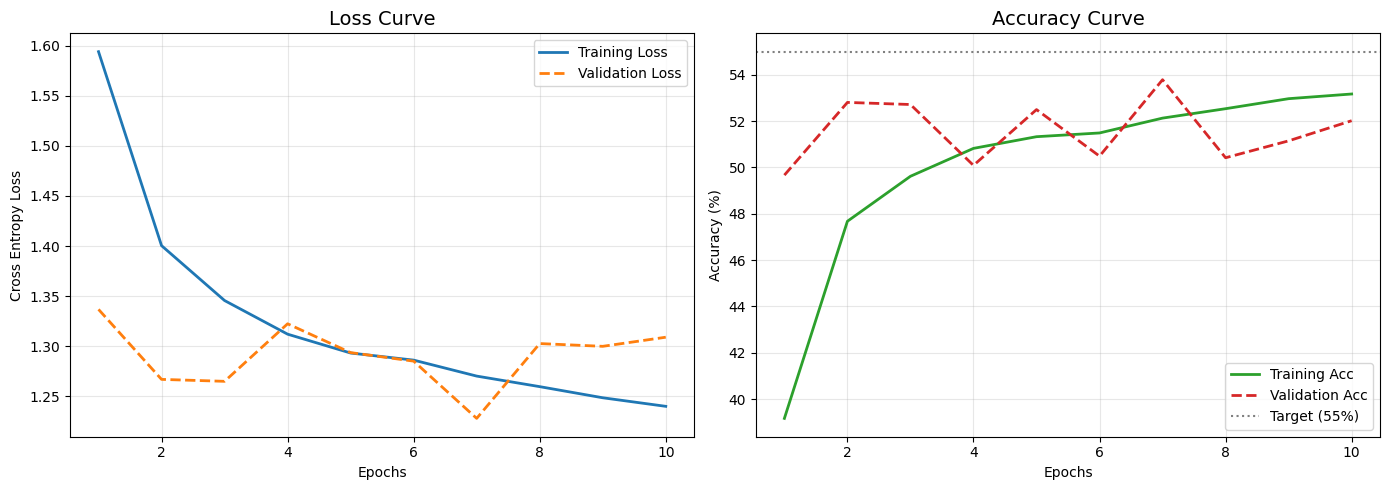

In [ ]:
plot_training_history(history)

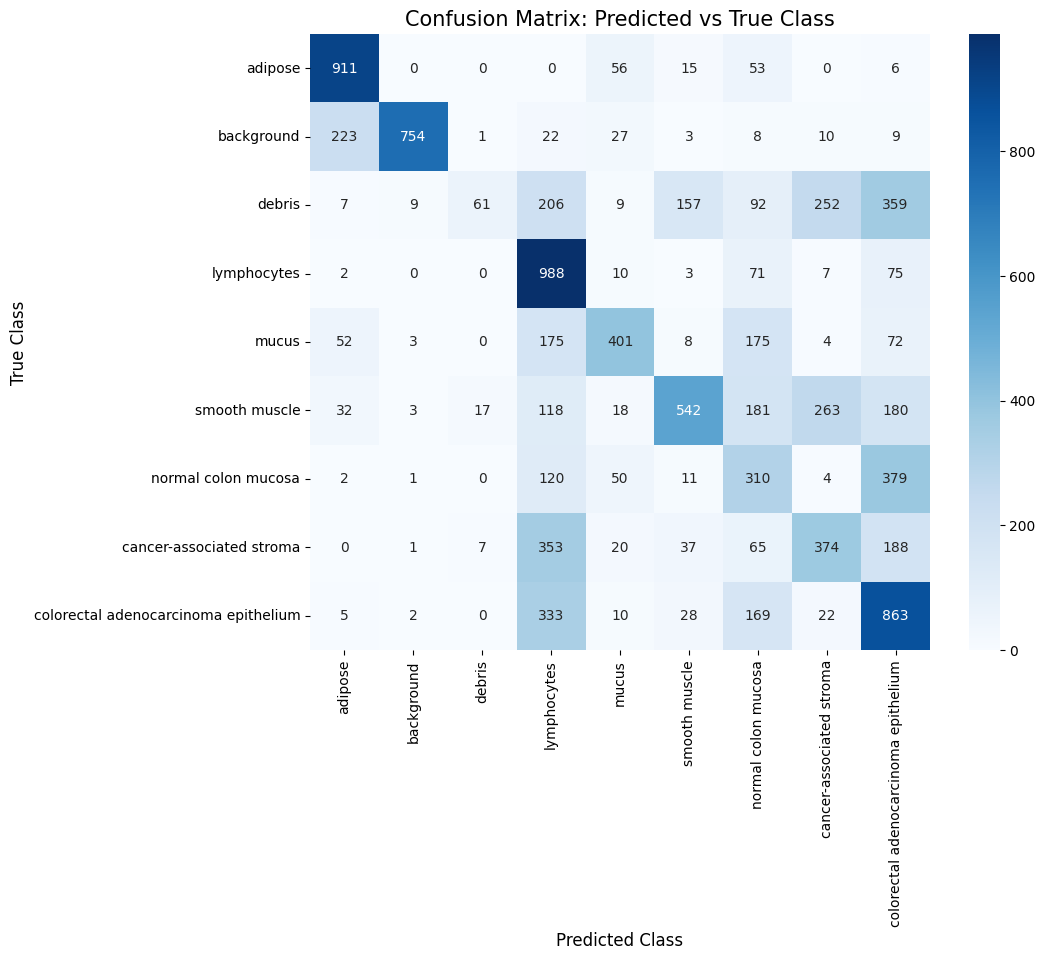

In [ ]:
class_names = [train_dataset.info['label'][str(i)] for i in range(9)]
cm = plot_confusion_matrix(baseline, val_loader, device, class_names);

In [ ]:
cm_errors = cm.copy()
np.fill_diagonal(cm_errors, 0)

In [ ]:
true_idx, pred_idx = np.unravel_index(np.argmax(cm_errors), cm_errors.shape)
max_error_count = cm_errors[true_idx, pred_idx]

print(f"Highest Misclassification: {max_error_count} instances")
print(f"True Class: {class_names[true_idx]} (Index {true_idx})")
print(f"Predicted as: {class_names[pred_idx]} (Index {pred_idx})")

Highest Misclassification: 379 instances
True Class: normal colon mucosa (Index 6)
Predicted as: colorectal adenocarcinoma epithelium (Index 8)


CNN

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class CNNFromScratch(nn.Module):
    def __init__(self, in_channels=3, num_classes=9, p_drop=0.3):
        super().__init__()

        # Block 1: 28x28 -> 14x14
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1, bias=True),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout2d(p_drop),
            nn.MaxPool2d(2)
        )

        # Block 2: 14x14 -> 7x7
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=True),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout2d(p_drop),
            nn.MaxPool2d(2)
        )

        # Block 3: 7x7 -> 7x7 (puis GAP)
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=True),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(p_drop)
        )

        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

cnn = CNNFromScratch(in_channels=3, num_classes=9, p_drop=0.3).to(device)
print(cnn)

CNNFromScratch(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.3, inplace=False)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.3, inplace=False)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.3, inplace=False)
  )
  (gap): AdaptiveAvgPool2d(output_size=(1, 1))
  (fc): Linear(in_fea

In [ ]:
# Q3.3 — Nombre total de paramètres entraînables
total_params = sum(p.numel() for p in cnn.parameters() if p.requires_grad)
print("Total trainable parameters:", total_params)

# Paramètres de la 1ère couche conv (block1[0])
conv1 = cnn.block1[0]
in_ch = conv1.in_channels      # 3
out_ch = conv1.out_channels    # 32
kH, kW = conv1.kernel_size     # (3,3)
bias = 1 if conv1.bias is not None else 0

conv1_params = out_ch * (in_ch * kH * kW + bias)
print("Conv1 params (computed):", conv1_params)

# Vérification avec PyTorch
conv1_params_torch = sum(p.numel() for p in conv1.parameters() if p.requires_grad)
print("Conv1 params (torch):", conv1_params_torch)

Total trainable parameters: 94857
Conv1 params (computed): 896
Conv1 params (torch): 896


In [ ]:
# Q3.1 — entraînement du CNN sans data augmentation
model = cnn
EPOCHS = 40

In [ ]:
def train_and_evaluate(model, train_loader, val_loader, criterion, optimizer, epochs, device):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        # --- TRAINING PHASE ---
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device).squeeze().long()

            # Forward + Backward
            outputs = model(images)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Stats
            train_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            train_correct += predicted.eq(labels).sum().item()
            train_total += labels.size(0)
            loop.set_postfix(loss=loss.item())

        # --- VALIDATION PHASE (Required for Q2.1) ---
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device).squeeze().long()
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                val_correct += predicted.eq(labels).sum().item()
                val_total += labels.size(0)

        # Store metrics
        history['train_loss'].append(train_loss / train_total)
        history['train_acc'].append(100. * train_correct / train_total)
        history['val_loss'].append(val_loss / val_total)
        history['val_acc'].append(100. * val_correct / val_total)

        print(f"Summary Epoch {epoch+1}: Val Loss: {history['val_loss'][-1]:.4f} | Val Acc: {history['val_acc'][-1]:.2f}%")

    return history

In [79]:
# Q3.1 — entraîner le CNN sans data augmentation (40 epochs)

model = cnn
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

history_cnn = train_and_evaluate(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=40,
    device=device
)

Epoch 1/40: 100%|██████████| 704/704 [00:28<00:00, 24.88it/s, loss=0.268]


Summary Epoch 1: Val Loss: 0.1949 | Val Acc: 93.63%


Epoch 2/40: 100%|██████████| 704/704 [00:26<00:00, 26.50it/s, loss=0.166]


Summary Epoch 2: Val Loss: 0.2096 | Val Acc: 92.83%


Epoch 3/40: 100%|██████████| 704/704 [00:25<00:00, 27.28it/s, loss=0.961]


...

Summary Epoch 38: Val Loss: 0.2388 | Val Acc: 91.69%


Epoch 39/40: 100%|██████████| 704/704 [00:26<00:00, 26.69it/s, loss=0.785]


Summary Epoch 39: Val Loss: 0.2024 | Val Acc: 93.12%


Epoch 40/40: 100%|██████████| 704/704 [00:26<00:00, 26.99it/s, loss=0.0347]


Summary Epoch 40: Val Loss: 0.1835 | Val Acc: 94.12%


In [80]:
# Q3.1 — Premier epoch où l'écart (train_acc - val_acc) dépasse 15 points
gaps = [tr - va for tr, va in zip(history_cnn["train_acc"], history_cnn["val_acc"])]

first_epoch = None
for i, g in enumerate(gaps):
    if g > 15:
        first_epoch = i + 1  # epochs commencent à 1
        break

print("Premier epoch avec gap > 15:", first_epoch)

if first_epoch is not None:
    i = first_epoch - 1
    print("Train acc (exact):", history_cnn["train_acc"][i])
    print("Val acc (exact):", history_cnn["val_acc"][i])
    print("Gap (exact):", gaps[i])
else:
    print("Aucun epoch où train_acc - val_acc > 15 sur ces 40 epochs.")

Premier epoch avec gap > 15: None
Aucun epoch où train_acc - val_acc > 15 sur ces 40 epochs.


Nous avons entraîné le CNN pendant 40 epochs sans data augmentation et analysé l’évolution de l’accuracy sur les ensembles d’entraînement et de validation. Afin de détecter un éventuel overfitting, nous avons calculé la différence entre train_acc et val_acc à chaque epoch. Sur l’ensemble des 40 epochs, cet écart n’a jamais dépassé 15 points de pourcentage. Cela suggère que le modèle ne présente pas d'overfitting important dans cette configuration et qu’il généralise relativement bien sur les données de validation.

CNN TEST accuracy: 0.8696378830083565


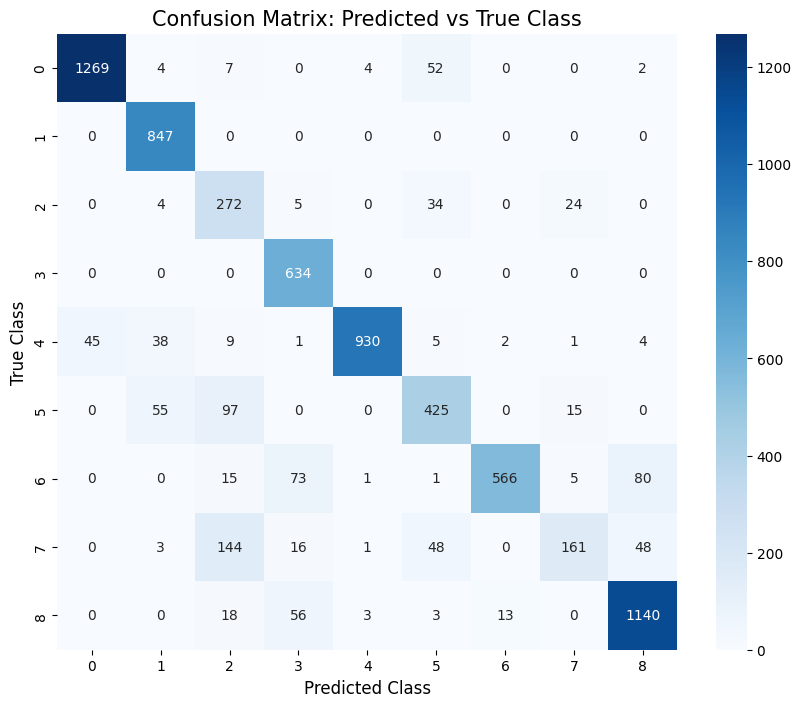

array([[1269,    4,    7,    0,    4,   52,    0,    0,    2],
       [   0,  847,    0,    0,    0,    0,    0,    0,    0],
       [   0,    4,  272,    5,    0,   34,    0,   24,    0],
       [   0,    0,    0,  634,    0,    0,    0,    0,    0],
       [  45,   38,    9,    1,  930,    5,    2,    1,    4],
       [   0,   55,   97,    0,    0,  425,    0,   15,    0],
       [   0,    0,   15,   73,    1,    1,  566,    5,   80],
       [   0,    3,  144,   16,    1,   48,    0,  161,   48],
       [   0,    0,   18,   56,    3,    3,   13,    0, 1140]])

In [81]:
# Q3.2 — Évaluation finale sur le jeu de test (accuracy + matrice de confusion)

@torch.no_grad()
def eval_test_acc(model, loader, device):
    model.eval()
    y_true, y_pred = [], []
    for x, y in loader:
        x = x.to(device)
        y = y.to(device).squeeze().long()
        logits = model(x)
        pred = torch.argmax(logits, dim=1)
        y_true.extend(y.cpu().numpy())
        y_pred.extend(pred.cpu().numpy())
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    acc = (y_true == y_pred).mean()
    cm = confusion_matrix(y_true, y_pred)
    return acc, cm

test_acc_cnn, test_cm_cnn = eval_test_acc(cnn, test_loader, device)
print("CNN TEST accuracy:", test_acc_cnn)

# noms des classes (PathMNIST)
class_names = INFO["pathmnist"]["label"]
plot_confusion_matrix(cnn, test_loader, device, class_names)

La matrice de confusion montre que la majorité des prédictions correctes se situent sur la diagonale, ce qui indique que le CNN classe correctement une grande partie des images du jeu de test. Certaines classes sont presque parfaitement reconnues, comme la classe 1 et la classe 3. Cependant, quelques confusions subsistent entre des classes visuellement proches, par exemple entre certaines images des classes 5 et 2 ou entre les classes 7 et 8. Globalement, les résultats montrent que le CNN capture mieux les structures spatiales des images que le modèle MLP utilisé précédemment, ce qui conduit à une amélioration significative des performances de classification